In [29]:
from pathlib import Path
from astropy.io import fits #para abrir ficheros fits
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter #Para realizar detrending (suavizar y estimar tendencia)
from lightkurve import LightCurve
from sklearn.ensemble import IsolationForest
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

IMPORTANTE: Se recomienda ejecutar el notebook celda por celda

En este cuaderno se ha desarrollado un modelo híbrido capaz de analizar curvas de luz, distinguiendo entre señales periódicas y no periódicas e identificando candidatos a anomalías, agrupándolas según su tipo. Para ello, se ha seguido el siguiente proceso:

1. Carga de archivos FITS

En esta primera fase se localizan los archivos FITS, descargados previamente de MAST,y se extrae el identificador TIC de la estrella y el número de puntos válidos según la columna de calidad. Esta información se almacena en un DataFrame, con la finalidad de facilitar su análisis posterior.

In [31]:
FITS_DIR = Path(r"C:\TESS") #guarda la ruta donde tenemos los archivos
fits_files = sorted(FITS_DIR.glob("*.fits")) #busca los archivos terminados en .fits y los ORDENAMOS 
print("N FITS:", len(fits_files)) #para ver cuántos hay

rows = [] #para guardar una fila de info de cada archivo
for f in fits_files:
    try:
        tic = int(fits.getval(f, "TICID", ext=0))  #Cada archivo fits tiene un valor TICID que indica el ID de la estrella estudiada
        #Abre los archivos y asegura que contengan datos con los que se puedan trabajar
        with fits.open(f) as hdul:  #uso with para que se cierre automáticamente al finalizar
            data = hdul[1].data #hdul es la extensión que se usa en fits. Se emte en la extensión 1 que es la que contiene los datos necesarios.
            #convierte QUALITY en un array de enteros
            q = np.array(data["QUALITY"], dtype=int) #Flags que indica si los puntos de datos de la curva de luz tiene calidad o si hubo algún problema instrumental
            n_good = int(np.sum(q == 0)) #Para saber cuantos datos buenos hay en la curva de luz
        rows.append({"tic_id": tic, "fits_path": str(f), "n_good_points": n_good})
    except Exception as e:
        print(f"Error procesando {f.name}: {e}") #en caso de error al abrir algún archivo

df_fits = pd.DataFrame(rows).drop_duplicates("tic_id") #quita duplicados (esto solo funciona si se trabaja con un solo sector) y los meteen un dataframe
df_fits.head(), len(df_fits)


N FITS: 5116


(    tic_id                                          fits_path  n_good_points
 0  1627611  C:\TESS\tess2019085135100-s0010-00000000016276...          14497
 1  1627709  C:\TESS\tess2019085135100-s0010-00000000016277...          14730
 2  1628071  C:\TESS\tess2019085135100-s0010-00000000016280...          14880
 3  1628320  C:\TESS\tess2019085135100-s0010-00000000016283...          14889
 4  1628550  C:\TESS\tess2019085135100-s0010-00000000016285...          14851,
 5116)

In [32]:
#Inspección de las extensiones disponibles de los archivos fits
row = df_fits.iloc[0]
fits_path = row["fits_path"]
fits.info(fits_path)

Filename: C:\TESS\tess2019085135100-s0010-0000000001627611-0140-s_lc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  LIGHTCURVE    1 BinTableHDU    167   18900R x 20C   [D, E, J, E, E, E, E, E, E, J, D, E, D, E, D, E, D, E, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 11)   int32   


Este paso fue necesario para entender que datos coger. En este caso, se necesita la extensión de LIGHTCURVE (hdul[1]), ya que es la que contiene los datos necesarios para el análisis (TIME, PDCSAP_FLUX y QUALITY):

In [33]:
hdul[1].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'CADENCENO'; format = 'J'; disp = 'I10'
    name = 'SAP_FLUX'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'SAP_FLUX_ERR'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'SAP_BKG'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'SAP_BKG_ERR'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'PDCSAP_FLUX'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'PDCSAP_FLUX_ERR'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'QUALITY'; format = 'J'; disp = 'B16.16'
    name = 'PSF_CENTR1'; format = 'D'; unit = 'pixel'; disp = 'F10.5'
    name = 'PSF_CENTR1_ERR'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'PSF_CENTR2'; format = 'D'; unit = 'pixel'; disp = 'F10.5'
    name = 'PSF_CENTR2_ERR'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'MOM_CENTR1'; format = 'D'; u

2. Preprocesado de las curvas de luz

En esta fase se define una función de preprocesado, encargada de leer cada curva de luz y preparar los datos para el análisis posterior.

En primer lugar, se extraen de la extensión LIGHTCURVE las siguientes columnas:
  
  TIME: Representa el eje temporal de la observación
  
  PDCSAP_FLUX: Flujo observado, corregido instrumentalmente
  
  QUALITY: Flag de calidad

Inicialmente, se hizo uso de la librería lightkurve, pero se optó por leer los archivos FITS utilizando astropy.io.fits. Esta decisión se tomó con la finalidad de tener un mayor control sobre el filtrado, la normalización y el tratamiento de las curvas de luz y así evitar resultados poco adecuados posteriores.

In [34]:
#Función preprocesado para limpieza de datos
def load_preprocess(fits_path, sg_window=101, sg_poly=3, min_points=300): #importa la ruta, el tamaño de la ventana, el orden de polinomio y el mínimo de puntos válidos
    with fits.open(fits_path) as hdul:
        data = hdul[1].data #Extensión 1
        time = np.array(data["TIME"], dtype=float) #Eje temporal (cuándo)
        flux = np.array(data["PDCSAP_FLUX"], dtype=float) #flujo observado - errores instrumentales (flujo ya corregido) (cuánto)
        quality = np.array(data["QUALITY"], dtype=int) #flag de calidad (fiable)

    #Elimina datos con un mal quality y NaNs y se queda solo con puntos válidos creando una máscara 
    mask = (quality == 0) & np.isfinite(time) & np.isfinite(flux) #que tengan calidad, que no sean NaN ni infinitos
    #Se lo aplicamos al flujo de luz y al tiempo
    time = time[mask]
    flux = flux[mask]

    #Descarta curvas de luz muy cortas, para evitar análisis poco fiables (curvas con menos de 300 puntos)
    if len(flux) < min_points:
        return None

    #Centra por la mediana, no la media. Dado que la media varía mucho y afectaría el análisis de forma negativa. 
    #Centralizando por la mediana, las anomalías no afecten al resto de la curva
    med = np.nanmedian(flux) #mediana del flujo
    std = np.std(flux) #desviación típica
    if std == 0 or not np.isfinite(std): #si es 0 o no es válida, se descarta
        return None
    flux_n = (flux - med) / std #Resta le mediana y divide entre la desviación típica
    #Con esto se logra que todas las curvas esten en una misma escala comparable

    #Se asegura que la ventana de savgol_filter no sea más grande que la curva y que sea impar.
    if sg_window >= len(flux_n):
        sg_window = len(flux_n) - 1 #Si es más grande, la reduce 
    if sg_window % 2 == 0: #Si es par, la convierte impar
        sg_window -= 1
    if sg_window < 5: #Se descartan curvas con ventanas muy pequeñas
        return None

    trend = savgol_filter(flux_n, sg_window, sg_poly) #Aplica el filtro con la finalidad de estimar una versión suavizada de la curva
    flux_d = flux_n - trend #Detrending (elimina la tendencia de la curva) con el fin de quedarse con eventos más interesantes.

    return time, flux_d #Devuelve tiempo y flujo sin tendencia


3. Detección de periodicidad

En esta fase se realiza un análisis previo de las curvas de luz, con la finalidad de detectar eventos repetitivos de carácter periódico en las curvas. Para ello se utilizan dos métodos:

   Box Least Squares (BLS): Para calcular bajas más profundas y extremas

   Lomb-Scargle (LS): Para calcular bajas menos profundas y suaves, de tipo sinusoidal

  Tras realizar estos cálculos, se categoriza la señal dependiendo de los valores obtenidos en los cálculos (valores de mayor potencia y periodos asociados a estos), con la función de periodicity_gate. Para BLS, se calcula también la duración, profundidad y el instante central del posible tránsito.
  
  Cada curva se etiqueta como BLS_strong, BLS_candidate, LS_strong, LS_candidate o nonperiodic. Los umbrales establecidos para cada categoría se han definido tras realizar distintas pruebas de ajuste.

  También, se hace un segundo análisis a las señales BLS, para subcategorizarlas por candidatas a tránsito (planet_candidate) o a sistema binario eclipsante (EB_candidate) con la función secondary_eclipse_strength
  
  Las curvas clasificadas como periódicas se almacenan en un dataframe, mientras que las no periódicas son analizadas posteriormente con otros métodos.

In [35]:
#BLS para calcular señales periódicas, sin saber el tipo específico
def compute_bls(time, flux, period_min=0.5, period_max=10.0): #usa periodo de entre 0.5 a 10 días
    lc = LightCurve(time=time, flux=flux).remove_nans() #crea y limpia la curva
    if len(lc) < 500: #descarta si es muy pequeña
        return None
    #busca el mejor periodo que explique la bajada por tránsito
    return lc.to_periodogram(
        method="bls",
        minimum_period=period_min,
        maximum_period=period_max,
    )

#Busca patrones periódicos más suaves, que cambien de tipo sinusoidal
def compute_ls(time, flux, period_min=0.5, period_max=10.0): #usa periodo de entre 0.5 a 10 días
    lc = LightCurve(time=time, flux=flux).remove_nans() #crea y limpia la curva
    if len(lc) < 500: #descarta si es muy pequeña
        return None
    #calcula periodograma como en BLS, pero con método LS
    return lc.to_periodogram(
        method="lombscargle",
        minimum_period=period_min,
        maximum_period=period_max
    )

#Flujo principal. Categoriza en: BLS_strong, BLS_candidate, LS_strong, LS_candidate, nonperiodic
def periodicity_gate(
    time, flux_d,
    bls_power_strong=0.05,
    bls_power_candidate=0.04,
    depth_sigma_strong=6.0,
    depth_sigma_candidate=5.0,
    ls_power_strong=0.006,
    ls_power_candidate=0.003
): #umbrales empíricos

    #Guarda resultados para analizarlos en el dataframe
    data = {
        "bls_power": 0.0, #potencia
        "bls_period": np.nan, #periodo
        "bls_t0": np.nan, #momento del tránsito     
        "bls_duration": np.nan, #duración
        "bls_depth": np.nan, #profundidad
        "bls_depth_sigma": 0.0,
        "ls_power": 0.0,
        "ls_period": np.nan
    }
    
    bls_label = None
    ls_label = None
    
    #Método robusto para estimar el ruido
    med = np.nanmedian(flux_d) #Calcula la mediana
    mad = np.nanmedian(np.abs(flux_d - med)) #Calcula MAD (medir como de separados están los puntos)
    if mad > 0:
        sigma = 1.4826 * mad #Para obtener una estimación equivalente a la desviación típica. 
        #Se utiliza para comparar la profundidad de las señales detectadas mediante BLS y reducir la aparición de FP.
    else:
        sigma = np.nanstd(flux_d) #Si no funciona, usa std (no es ideal, porque es sensible a ruido)

    #Calcula BLS
    bls = compute_bls(time, flux_d)
    if bls is not None and np.isfinite(bls.max_power.value): #Comprueba que no falle y que el power máximo sea un número válido

        #Se queda con el mejor periodo 
        data["bls_power"] = float(bls.max_power.value) #power mejor pico
        data["bls_period"] = float(bls.period_at_max_power.value) #mejor periodo
        data["bls_t0"] = float(bls.transit_time_at_max_power.value) #tiempo ref. 
        data["bls_duration"] = float(bls.duration_at_max_power.value) #duracion periodo

        #Para saber cuánto varía el brillo
        depth = None
        if hasattr(bls, "depth_at_max_power"): #Se asegura de que exista con has attribuye
            depth = float(bls.depth_at_max_power.value)

        data["bls_depth"] = depth if depth is not None else np.nan #Guarda la profundidad si existe, sino Nan

        depth_sigma = abs(depth)/sigma if (depth is not None and sigma>0) else 0 #Compara ruido con la variación y cuenta cuántas veces la profundidad supera al ruido
        #Es necesario para evitar falsos positivos. Sino siempre va a tender a encontrar un periodicidad.
        data["bls_depth_sigma"] = float(depth_sigma)
        
        #Si la potencia es alta y la diferencia entre profundidad y ruido también lo es, se categoriza como candidato fuerte
        if (data["bls_power"] >= bls_power_strong and
            depth_sigma >= depth_sigma_strong):
            bls_label = "BLS_strong"
        #Si no es muy alta, pero suficiente, lo categoriza como candidato
        elif (data["bls_power"] >= bls_power_candidate and
            depth_sigma >= depth_sigma_candidate):
            bls_label =  "BLS_candidate"

    #Calcula LS
    ls = compute_ls(time, flux_d)
    if ls is not None and np.isfinite(ls.max_power.value):

        #Aquí no usa depth y  además, los valores utilizados siempre van a estar disponibles
        data["ls_power"] = float(ls.max_power.value)
        data["ls_period"] = float(ls.period_at_max_power.value)

        #Si la potencia es alta, se categoriza como candidato fuerte
        if data["ls_power"] >= ls_power_strong:
            ls_label = "LS_strong"

        #Si no es muy alta, pero suficiente, lo categoriza como candidato
        elif data["ls_power"] >= ls_power_candidate:
            ls_label =  "LS_candidate"

   #Método de decisión importante, ya que sino BLS categoriza incluso aquellas señales más candidatas a ser de tipo LS
    
   #Si solo uno de los dos es strong, este tiene prioridad
    if bls_label == "BLS_strong" and ls_label != "LS_strong":
        return "BLS_strong", data

    if ls_label == "LS_strong" and bls_label != "BLS_strong":
        return "LS_strong", data

    #Si ambos son strong:
    if bls_label == "BLS_strong" and ls_label == "LS_strong":
        #Si BLS tiene una profundidad significativa, prioriza BLS
        if data["bls_depth_sigma"] >= depth_sigma_strong:
            return "BLS_strong", data
        else:
            return "LS_strong", data
            
    #Si solo uno es candidato:
    if bls_label == "BLS_candidate" and ls_label is None:
        return "BLS_candidate", data

    if ls_label == "LS_candidate" and bls_label is None:
        return "LS_candidate", data

    #Si ambos son candidatos:
    if bls_label == "BLS_candidate" and ls_label == "LS_candidate":

        #Si LS es alto y BLS no es muy profundo, escoge LS
        if data["ls_power"] >= ls_power_candidate and data["bls_depth_sigma"] < depth_sigma_strong:
            return "LS_candidate", data

        #Si BLS es más profundo, escoge BLS
        return "BLS_candidate", data
        
    #Si ninguno supera umbrales:
    return "nonperiodic", data

#Coge los resultados de BLS y hace una subclasificación, para entender si es  candidata a tipo tránsito o una binaria eclipsante (EB)
def secondary_eclipse_strength(time, flux, period, t0): #tiempo, flujo, periodo y y el punto central
    #Convierte tiempo en fase orbital
    phase = ((time - t0) / period) % 1 #Convierte los tiempos en posiciones/fases para que sea más manejable) y los pliega todos en uno

    mask_primary = (phase < 0.05) | (phase > 0.95) #Selecciona puntos donde se encontró el tránsito
    mask_secondary = (phase > 0.45) & (phase < 0.55) #Selecciona puntos en la zona próxima a la primaria
    mask_out_of_eclipse = (phase > 0.1) & (phase < 0.4) | (phase > 0.6) & (phase < 0.9) #Zonas en las que supuestamente no hay variaciones/normales

    if np.sum(mask_primary) < 10 or np.sum(mask_secondary) < 10 or np.sum(mask_out_of_eclipse) < 10: #Cuenta cuántos puntos hay en cada máscara y si no son suficientes se descarta
        return np.nan, np.nan

    baseline = np.median(flux[mask_out_of_eclipse]) #Calcula lo que brilla la estrella habitualmente cuando no hay fluctuaciones (mediana para evitar ruido)
    depth_primary = baseline - np.median(flux[mask_primary]) #Calcula la profundidad en la primera zona 
    depth_secondary = baseline - np.median(flux[mask_secondary]) #Lo mismo con la segunda

    return depth_primary, depth_secondary

4. Segmentación de curvas en ventanas temporales

   En este punto creamos una función que divida las curvas categorizadas como no periódicas en ventanas para su posterior análisis.

In [36]:
def make_windows(time, flux, window=200, step=50): 
    #Corta la ventana en 200 puntos y avanza 50 cada vez para que se solapen y evitar que haya anomalías sin detectar
    X = [] #array ventanas
    t_win = [] #long ventanas
    for i in range(0, len(flux) - window + 1, step):
        X.append(flux[i:i+window])
        t_win.append((time[i], time[i+window-1]))
    return np.array(X), np.array(t_win)


5. Detección de anomalías con Isolation Forest

Tras generar las ventanas, aplicamos Isolation Forest en cada una de ellas con el fin de identificar anomalías en estas.

Isolation Forest es un método de aprendizaje no supervisado creado para detectar comportamientos atípicos. En este caso, se entrena con los datos de las curvas de luz extraídas y se calcula una puntuación de anomalía para cada ventana. Cuánto mayor es el valor, mayor es la probabilidad de anomalía.

In [37]:
#Entrena IsoForest con las ventanas X para que vea cuáles le parecen anómalas
def compute_isolation_forest_scores(X, contamination=0.01, random_state=13):
    #contamination: se espera que un 1% de las ventanas sean anómalas
    #random state: para que los resultados siempre sean los mismos

    #Crea el modelo
    model = IsolationForest(
        n_estimators=300, #Número arboles
        contamination=contamination, 
        random_state=random_state,
        n_jobs=-1 #Para que funcione rápido
    )
    model.fit(X) #Entrena el modelo
    anomaly_scores = -model.score_samples(X) #Los valores altos son los más raros
    return anomaly_scores


6. Detección impulsos y eventos extremos

Además de Isolation Forest, se vió necesario implementar métodos adicionales para calcular eventos más extremos e impulsivos.

Para ello, se hace uso de un z-score robusto basado en el MAD, que identifica puntos extremos en los segmentos y agrupa los índices consecutivos para estimar el nº de impulsos presentes en la ventana.

In [38]:
def robust_z(x):
    x = np.asarray(x) #Convierte en array de Numpy
    #Cálculo robusto del centro y de la dispersión:
    med = np.nanmedian(x) #Calcula la mediana ignorando los nan
    mad = np.nanmedian(np.abs(x - med)) #Calcula la medida mad
    if not np.isfinite(mad) or mad == 0: #Si mad no funciona 
        mad = np.nanstd(x) + 1e-12 #Hace desviación estandar
    return (x - med) / (1.4826 * mad) #Devuelve z-score robusto

#Cuenta puntos extremos en las VENTANAS
def count_impulses(segment, z_thr=5.0): #threshold para detectar eventos sutiles
    z = robust_z(segment) #Calcula la rareza robusta del segmento
    idx = np.where(np.abs(z) > z_thr)[0] #El indice donde están los puntos
    if len(idx) == 0: #Si no hay, devuelve 0
        return 0
    groups = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1) #los agrupa los indices consecutivos en grupos  y cuenta cuántos hay
    return len(groups)

7. Extracción de características de las ventanas

En este punto, se calculan características estadísticas de las ventanas temporales para describir la forma y variabilidad de las curvas, y para poder utilizarlas más adelante en los clusters. Estas métricas son:

Desviación típica

Rango

Percentiles

Asimetría

Curtosis

Señal asociada a tipo tránsito

Nº de impulsos

In [39]:
def window_features(segment):
    segment = np.asarray(segment) 
    segment = segment[np.isfinite(segment)] #ELimina nans e infinitos
    if len(segment) < 10: #Descarta ventanas muy pequeñas
        return None

    p5, p50, p95 = np.percentile(segment, [5, 50, 95]) #Calcula percentiles

    feats = {
        "w_std": float(np.std(segment)), #Desviación estandar: cuánto varía la señal (bajo es plana, alto es variable)
        "w_mad": float(np.median(np.abs(segment - np.median(segment)))), #MAD
        "w_range": float(np.max(segment) - np.min(segment)),#Rango total
        "w_min": float(np.min(segment)),#Punto más bajo
        "w_max": float(np.max(segment)),#punto más alto
        "w_p5": float(p5), #percentiles
        "w_p50": float(p50),#percentiles
        "w_p95": float(p95),#percentiles
        "w_skew": float(skew(segment)),#Mide asimetría. skew=0 es simétrico, skew<0 tipo tránsito/eclipse (pico hacia abajo), skew>0 pico hacia arriba (ruido, etc)
        "w_kurt": float(kurtosis(segment, fisher=True)),#Mide los dips (curtosis), valores extremos
        "transitlike": float(-p5),#Score de caidas
        "n_impulses": int(count_impulses(segment, z_thr=6.0)),
    }
    return feats

7. Comprobaciones

   Se realizan varias pruebas y mostramos resultados para comprobar que la detección ha funcionado correctamente

In [40]:
#Coge la primera fila del dataframe y selecciona el TIC de la estrella
row = df_fits.iloc[0]
tic = int(row["tic_id"])
fits_path = row["fits_path"]

#Depuración
result = load_preprocess(fits_path) #Llama a la función de preprocesado para limpiar y normalizar la curva
if result is None:
    print(f"No se pudo procesar el TIC {tic}")
else:
    time, flux_detrended = result

#Coge las ventanas y el rango temporal de cada una
X, t_win = make_windows(time, flux_detrended, window=200, step=50)
if len(X) == 0:
    print(f"No hay ventanas suficientes para {tic}")

anomaly_scores  = compute_isolation_forest_scores(X, contamination=0.01)

if len(anomaly_scores) == 0:
    print(f"TIC: {tic} | 0 ventanas útiles")

print(f"TIC {tic} | ventanas: {len(anomaly_scores)} | score max: {anomaly_scores.max()}")

TIC 1627611 | ventanas: 286 | score max: 0.4563561338543695


In [41]:
#Muestra tabla con los 10 TICs más anómalos y su puntuación
import numpy as np
import pandas as pd

resultados_anom = []

for _, row in df_fits.iterrows():
    tic = int(row["tic_id"])
    fits_path = row["fits_path"]

    result = load_preprocess(fits_path)
    if result is None:
        continue

    time, flux_detrended = result

    X, t_win = make_windows(time, flux_detrended, window=200, step=50)
    if len(X) == 0:
        continue

    anomaly_scores = compute_isolation_forest_scores(X, contamination=0.01)
    if len(anomaly_scores) == 0:
        continue

    idx_max = np.argmax(anomaly_scores)

    resultados_anom.append({
        "tic_id": tic,
        "score_max": float(anomaly_scores[idx_max]),
        "idx_max": int(idx_max),
        "time_window": t_win[idx_max],
        "flux_window": X[idx_max]
    })

#Convierte a DataFrame
df_anom = pd.DataFrame(resultados_anom)

#Ordena de mayor a menor score
df_anom = df_anom.sort_values("score_max", ascending=False).reset_index(drop=True)

#Muestra los 10 más anómalos
df_anom[["tic_id", "score_max"]].head(10)

,tic_id,score_max
0,118307280,0.803611
1,140859822,0.798728
2,101690410,0.787810
3,46029665,0.756727
4,29779873,0.751901
5,150429807,0.751733
6,33878971,0.750955
7,44984200,0.750401
8,22390773,0.743837
9,165909066,0.741419


8. Pipeline principal

   En esta fase, se ejecuta el flujo principal de análisis sobre todas las curvas disponibles.

   Para cada archivo FITS, primero se realiza una etapa de preprocesado de la curva. A continuación, se realiza un análisis de periodicidad mediante los métodos de BLS y Lomb-Scargle.

   Las curvas periódicas se almacenan juntas con sus respectivos datos extraídos del periodograma. Sin embargo, las curvas clasificadas como no periódicas se dividen en ventanas temporales y se analizan con Isolation Forest. Finalmente, se contruyen dos Dataframes:

   df_periodic: Contiene las curvas clasificadas como periódicas y sus datos

   df_events: Contiene las ventanas anómalas de las curvas clasificadas como no periódicas

In [42]:
#FLUJO PRINCIPAL

events = [] #Ventanas anómalas de curvas NO periodicas
periodic_stars = [] #Curvas periódicas

WINDOW = 200 #tamaño de la ventana
STEP = 50 #cuánto avanzamos por ventana
CONTAM = 0.01 #prop. de anomalías de Isolation Forest

for _, row in df_fits.iterrows(): #Recorre las filas de dataframe de los fits creado al inicio del cuaderno
    tic = int(row["tic_id"])
    fits_path = row["fits_path"]

    result = load_preprocess(fits_path) #Preprocesado
    if result is None:
        continue
    time, flux_d = result

    #Calcula periodicidad
    label, period_data = periodicity_gate(time, flux_d)

    #Si la curva es periodica, guarda la estrella en periodic_stars con sus datos + la info de periodicity_gate
    if label != "nonperiodic":
        periodic_stars.append({
            "tic_id": tic,
            "fits_path": fits_path,
            "periodic_type": label,
            **period_data
        })
        continue #Continúa, no calcula anomalías

    #Si no es periodica, lo divide en ventanas
    X, t_win = make_windows(time, flux_d, window=WINDOW, step=STEP) #X son las ventanas y t_win el rango temporal de cada una
    if len(X) < 10: #comprueba que hay suficientes ventanas
        continue
    #Calcula el score con isoforest 
    #Selecciona las ventanas más anómalas para analizarlas, no todas:
    scores = compute_isolation_forest_scores(X, contamination=CONTAM)
    score_threshold = np.percentile(scores, 99)
    idx = np.where(scores >= score_threshold)[0]
    if len(idx) == 0:
        idx = np.argsort(scores)[-3:]  #Mínimo 3 eventos por estrella

    #Para cada ventana, calcula sus features
    for i in idx:
        feats = window_features(X[i])
        if feats is None: #Si no funciona, la saltamos
            continue

        t0_win, t1_win = t_win[i] #Saca el inicio y el final de esa ventana

        #Actualiza los features
        feats.update({
            "tic_id": tic,
            "fits_path": fits_path,
            "t0": float(t0_win),
            "t1": float(t1_win),
            "iforest_score": float(scores[i]),
        })

        #Guarda la ventana en la lista de eventos
        events.append(feats)

#Contruye los dataframes:
df_events = pd.DataFrame(events)
df_periodic = pd.DataFrame(periodic_stars)

# Añade columna para subtipo BLS (exoplaneta/EB/indefinido)
df_periodic["bls_subtype"] = None

mask_bls = df_periodic["periodic_type"].isin(["BLS_strong", "BLS_candidate"])

for idx, r in df_periodic[mask_bls].iterrows():
    out = load_preprocess(r["fits_path"])

    if out is None:
        df_periodic.loc[idx, "bls_subtype"] = "uncertain"
        continue

    time, flux_d = out

    d1, d2 = secondary_eclipse_strength(
        time,
        flux_d,
        float(r["bls_period"]),
        float(r["bls_t0"])
    )

    if np.isnan(d1) or np.isnan(d2) or d1 <= 0:
        df_periodic.loc[idx, "bls_subtype"] = "uncertain"
        continue

    df_periodic.loc[idx, "bls_subtype"] = (
        "EB_candidate" if d2 > 0.5 * d1 else "Planet_candidate"
    ) #si el eclipse secundario encontrado es lo suficientemente grande con respecto al primero, lo clasifica como EB, sino lo deja como exoplaneta
#Muestra resultados periódicos
print(df_periodic["periodic_type"].value_counts())
print(df_periodic["bls_subtype"].value_counts(dropna=False))

display(
    df_periodic[
        ["tic_id", "periodic_type", "bls_power",
         "bls_period", "ls_power", "ls_period", "bls_subtype"]
    ].sort_values(["periodic_type", "bls_subtype"])
)

#Muestra resumen general
print("Eventos no periódicos:", len(df_events))
print("Estrellas periódicas:", len(df_periodic))
print(df_periodic["periodic_type"].value_counts() if len(df_periodic) else "Sin periódicas")

periodic_type
LS_candidate     127
BLS_strong        26
BLS_candidate      8
Name: count, dtype: int64
bls_subtype
None                127
Planet_candidate     16
uncertain            12
EB_candidate          6
Name: count, dtype: int64


,tic_id,periodic_type,bls_power,bls_period,ls_power,ls_period,bls_subtype
69,77557473,BLS_candidate,405.069807,0.581426,0.002886,0.846200,EB_candidate
77,92997988,BLS_candidate,5.115952,7.936672,0.001114,0.535671,EB_candidate
12,22390773,BLS_candidate,1.093538,7.549147,0.000702,0.538165,Planet_candidate
14,22507789,BLS_candidate,173.048061,8.526337,0.000333,0.532607,Planet_candidate
16,25078924,BLS_candidate,180.567248,0.904584,0.000392,7.086101,Planet_candidate
...,...,...,...,...,...,...,...
156,167309586,LS_candidate,2.796444,9.032311,0.003797,0.528169,None
157,167340913,LS_candidate,1.827143,7.269034,0.003073,0.511272,None
158,167523976,LS_candidate,5.951290,7.096934,0.004737,0.509143,None
159,167548698,LS_candidate,4.502784,7.850687,0.003607,7.085234,None


Eventos no periódicos: 15562
Estrellas periódicas: 161
periodic_type
LS_candidate     127
BLS_strong        26
BLS_candidate      8
Name: count, dtype: int64


9. Clustering

    Una vez construído el dataframe de eventos anómalos de curvas no periódicas, se aplica un proceso de clustering para agrupar estos eventos según sus características: dispersión, rango, percentiles, asimetría, curtosis, intensidad de caídas y número de impulsos. Estas variables han sido escaladas previamente, con el fin de evitar que aquellas con un rango mayor dominen el agrupamiento.

Después, se aplica reducción de dimensionalidad mediante PCA, apra poder representar los eventos en un esacio más compacto. Esto facilita la visualización y el análisis.

Para seleccionar el número de clusters más adecuado, se hace uso del coeficiente de Silhouette, que mide el grado de separación y cohesión entre los grupos. De esta forma, se asegura que los clusters están bien formados.

Por último, se utiliza K-Means para agrupar los eventos anómalos en clusters, dependiendo de su tipo de comportamiento.

In [43]:
feature_cols = [
    "iforest_score", "w_std", "w_mad", "w_range", "w_min", "w_max",
    "w_p5", "w_p50", "w_p95", "w_skew", "w_kurt", "transitlike", "n_impulses"
]

X = df_events[feature_cols].replace([np.inf, -np.inf], np.nan).dropna() #Coge las columnas de features y limpia (cambia inf. por Nans, y elimina columnas con Nans)
df_ml = df_events.loc[X.index].copy() #Crea una copia limpia para el ML

scaler = RobustScaler() #Crea el objeto para escalar
X_scaled = scaler.fit_transform(X) #Transforma datos para que TODO sea escalable

In [44]:
pca = PCA(n_components=6, random_state=42) #Usa PCA para resumir todos los datos en 6 features
Z = pca.fit_transform(X_scaled) #Aplica el PCA a los datos escalados anteriormente
explained = pca.explained_variance_ratio_.sum()
print("Porcentaje datos explicados", explained) #Para ver si el valor 6 cubre suficiente o no

#Uso de silhouette para elegir el mejor k
best_k, best_s = None, -1 #Mejor k (numero clusters) y mejor score (en -1 porque silhouette empieza en -1)
for k in range(3, 11): #Prueba entre 3 y 11 grupos
    km = KMeans(n_clusters=k, random_state=42, n_init="auto") #Divide los datos en k grupos
    labels = km.fit_predict(Z) #Entrena y asigna clusters a los datos
    s = silhouette_score(Z, labels) #Calcula la calidad del cluster
    #Cuanto más alto el valor, mejor separados, mejor calidad
    #Compara con el anterior guardado. Si es mejor, se guarda
    if s > best_s:
        best_k, best_s = k, s

km = KMeans(n_clusters=best_k, random_state=42, n_init="auto") #Crea el modelo final tras elegir el mejor k means (auto para que ejecute varias con esta configuración)
df_ml["cluster"] = km.fit_predict(Z) #Entrena Kmeans y crea un cluster para cada evento

best_k, best_s, df_ml["cluster"].value_counts() #Muestra los datos

Porcentaje datos explicados 0.9894095204268896


(3,
 0.8516665616018931,
 cluster
 0    15327
 2      162
 1       73
 Name: count, dtype: int64)

10. Resultados

10.1. Resultados no periódicos

In [45]:
df_ml.groupby("cluster")[feature_cols].median().T

cluster,0,1,2
iforest_score,0.460567,0.573610,0.525981
w_std,1.081010,3.150552,1.859472
w_mad,0.705119,0.821497,0.615598
w_range,5.947757,36.202722,16.253341
w_min,-2.703609,-4.847268,-3.219391
w_max,3.091364,30.291451,12.699574
w_p5,-1.689108,-3.138296,-1.879741
w_p50,-0.016391,-0.211829,-0.101601
w_p95,1.751501,2.015148,1.655508
w_skew,0.151906,6.215796,3.725681


In [46]:
df_ml.groupby("cluster")[feature_cols].mean().T

cluster,0,1,2
iforest_score,0.466057,0.572358,0.556036
w_std,0.981590,3.471111,2.034963
w_mad,0.648049,0.774936,0.600684
w_range,5.638206,38.499028,17.471445
w_min,-2.567097,-4.662266,-3.532637
w_max,3.071108,33.836762,13.938809
w_p5,-1.554072,-3.184298,-2.321758
w_p50,-0.018932,-0.205431,-0.117817
w_p95,1.613778,2.045765,2.208938
w_skew,0.192320,6.363994,3.708182


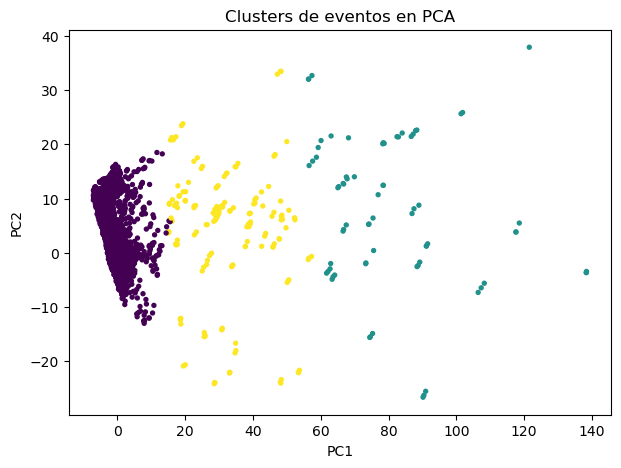

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(Z[:,0], Z[:,1], c=df_ml["cluster"], s=8)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Clusters de eventos en PCA")
plt.show()

In [ ]:
#CLuster 0

def plot_event(row, window=200, step=50):
    tic = int(row["tic_id"])
    out = load_preprocess(row["fits_path"])
    if out is None:
        return
    time, flux_d = out

    plt.figure(figsize=(12,4))
    plt.plot(time, flux_d, lw=0.8)
    plt.axvspan(row["t0"], row["t1"], alpha=0.25)
    plt.title(f"TIC {tic} | cluster {row['cluster']}")
    plt.xlabel("Tiempo (BTJD)")
    plt.ylabel("Flux detrended")
    plt.show()
    
cl = 0
sample = df_ml[df_ml["cluster"]==cl].sample(300, random_state=42)
for _, r in sample.iterrows():
    plot_event(r)

In [ ]:
#CLuster 1
def plot_event(row, window=200, step=50):
    tic = int(row["tic_id"])
    out = load_preprocess(row["fits_path"])
    if out is None:
        return
    time, flux_d = out

    plt.figure(figsize=(12,4))
    plt.plot(time, flux_d, lw=0.8)
    plt.axvspan(row["t0"], row["t1"], alpha=0.25)
    plt.title(f"TIC {tic} | cluster {row['cluster']} | score {row['iforest_score']:.3f}")
    plt.xlabel("Tiempo (BTJD)")
    plt.ylabel("Flux detrended")
    plt.show()

cl = 1
sample = df_ml[df_ml["cluster"]==cl].sample(100, random_state=42)
for _, r in sample.iterrows():
    plot_event(r)

In [ ]:
#Cluster 2
def plot_event(row, window=200, step=50):
    tic = int(row["tic_id"])
    out = load_preprocess(row["fits_path"])
    if out is None:
        return
    time, flux_d = out

    plt.figure(figsize=(12,4))
    plt.plot(time, flux_d, lw=0.8)
    plt.axvspan(row["t0"], row["t1"], alpha=0.25)
    plt.title(f"TIC {tic} | cluster {row['cluster']} | score {row['iforest_score']:.3f}")
    plt.xlabel("Tiempo (BTJD)")
    plt.ylabel("Flux detrended")
    plt.show()

cl = 2
sample = df_ml[df_ml["cluster"]==cl].sample(60, random_state=42)
for _, r in sample.iterrows():
    plot_event(r)

10.2. Resultados periódicos

In [ ]:
cols = ["tic_id","periodic_type",
        "bls_power","bls_period","bls_t0","bls_duration","bls_depth",
        "ls_power","ls_period"]
df_periodic[cols].sort_values(["periodic_type","tic_id"])

import matplotlib.pyplot as plt
import numpy as np

def plot_periodic_tic(tic_id):
    row = df_periodic[df_periodic["tic_id"] == tic_id].iloc[0]
    fits_path = row["fits_path"]
    ptype = row["periodic_type"]
    bls_sub = row["bls_subtype"]

    out = load_preprocess(fits_path)
    if out is None:
        print("No se pudo cargar:", tic_id)
        return
    time, flux_d = out

    # Curva completa con scatter para no dibujar el gap
    plt.figure(figsize=(12,3))
    plt.scatter(time, flux_d, s=1)
    plt.title(f"TIC {tic_id} - {ptype} (full)")
    plt.xlabel("Time"); plt.ylabel("Flux detrended")
    plt.show()

    # Phase-fold según el tipo
    if "LS" in ptype:
        P = float(row["ls_period"])
        if not np.isfinite(P):
            print("No hay ls_period para", tic_id)
            return
        phase = (time % P) / P
        plt.figure(figsize=(6,4))
        plt.scatter(phase, flux_d, s=1)
        plt.title(f"TIC {tic_id} - Phase-fold LS (P={P:.4f} d)")
        plt.xlabel("Phase"); plt.ylabel("Flux detrended")
        plt.show()

    if "BLS" in ptype:
        P = float(row["bls_period"])
        t0 = float(row["bls_t0"])
        if not (np.isfinite(P) and np.isfinite(t0)):
            print("No hay bls_period/t0 para", tic_id)
            return
        phase = ((time - t0) % P) / P
        plt.figure(figsize=(6,4))
        plt.scatter(phase, flux_d, s=1)
        plt.title(f"TIC {tic_id} - Phase-fold BLS (P={P:.4f} d)")
        plt.xlabel("Phase"); plt.ylabel("Flux detrended")
        plt.show()

for _, r in df_periodic.sort_values("periodic_type").iterrows():
    tic = int(r["tic_id"])
    print("TIC:", tic, "|", r["periodic_type"])
    print("BLS:", "power", r.get("bls_power", np.nan), "subtype", r.get("bls_subtype",np.nan), "P", r.get("bls_period", np.nan), "depth", r.get("bls_depth", np.nan))
    print("LS :", "power", r.get("ls_power", np.nan), "P", r.get("ls_period", np.nan))
    plot_periodic_tic(tic)